<a href="https://colab.research.google.com/github/laramalkawi81-ops/DS230-Instacart-Project/blob/main/Copy_of_Copy_of_07_models_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Models Comparison
Model Training, Evaluation & Comparison

In this notebook, we train and compare multiple machine learning models
for both classification (reorder prediction) and regression (Task B).

We use a sampled dataset to reduce memory usage and ensure stable execution.


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
print(data.columns)

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered',
       'product_freq', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order',
       'days_since_prior_order_scaled', 'total_orders',
       'mean_days_between_orders', 'product_reorder_rate',
       'product_purchase_count', 'user_product_count',
       'user_product_reorder_rate', 'order_hour', 'reorder_count'],
      dtype='object')


In [48]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor



We import common machine learning models and evaluation metrics.
All models are from scikit-learn to ensure fair comparison.


data_loading

In [49]:

data = pd.read_csv('/content/drive/MyDrive/instacart_data/model_data_sample.csv')


data = data.sample(n=100_000, random_state=42)

data.head()


,order_id,product_id,add_to_cart_order,reordered,product_freq,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,days_since_prior_order_scaled,total_orders,mean_days_between_orders,product_reorder_rate,product_purchase_count,user_product_count,user_product_reorder_rate,order_hour
5443703,2839892,7693,30,1,0.000118,137629,prior,90,5,14,4.0,-0.692348,100,3.630000,0.715933,954,42,0.976190,14
4624248,2412939,47683,18,1,0.000037,111603,prior,4,4,8,7.0,-0.370070,17,6.588235,0.589372,207,12,0.916667,8
3626864,1891520,40396,4,1,0.000554,87435,prior,10,4,15,8.0,-0.262644,25,12.120000,0.661400,3671,4,0.750000,15
3528021,1838620,15866,5,1,0.000015,68985,prior,9,1,10,3.0,-0.799774,49,6.979592,0.653846,104,12,0.916667,10
4831041,2520082,14702,4,1,0.000127,177234,prior,27,1,8,14.0,0.381913,42,8.690476,0.826419,916,10,0.900000,8


### Data Loading
We load the final engineered dataset and use a small random sample
to avoid memory issues during model training.


Task A – Classification

In [50]:

y_class = data['reordered']
X = data.drop(columns=['reordered'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)



The goal is to predict whether a product will be reordered.
We split the data into training and testing sets.


Scaling

In [51]:
scaler = StandardScaler()


numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled  = scaler.transform(X_test[numeric_cols])


import pandas as pd

X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=numeric_cols)

Classification Model Training

In [52]:
models_classification = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10)
}

results_classification = []

for name, model in models_classification.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    results_classification.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    })

results_classification = pd.DataFrame(results_classification)
results_classification


,Model,Accuracy,F1
0,Logistic Regression,0.85885,0.883775
1,KNN,0.85325,0.881906
2,Decision Tree,0.88725,0.906163
3,Random Forest,0.89140,0.913837



We train several baseline classifiers and compare them
using Accuracy and F1-score.


Model comparison chart

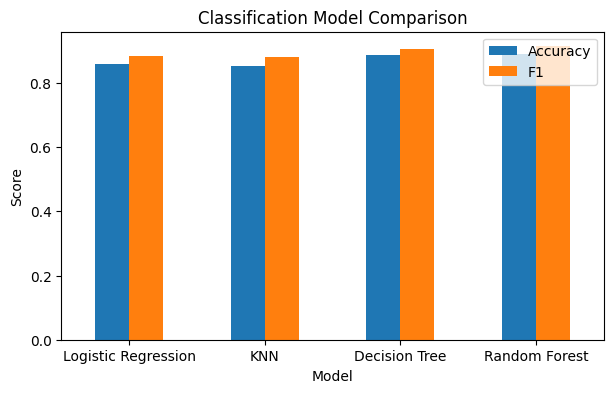

In [53]:
results_classification.set_index('Model')[['Accuracy', 'F1']].plot(
    kind='bar', figsize=(7,4)
)

plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


Task B – Regression

In [54]:
data['reorder_count'] = data.groupby(['user_id', 'product_id'])['reordered'].transform('sum')

In [55]:
print(data[['user_id','product_id','reordered','reorder_count']].head())

         user_id  product_id  reordered  reorder_count
5443703   137629        7693          1              1
4624248   111603       47683          1              1
3626864    87435       40396          1              1
3528021    68985       15866          1              1
4831041   177234       14702          1              1


In [62]:
y_reg = data['reorder_count']
X_reg = data.drop(columns=['reorder_count', 'reordered'])

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

numeric_cols = X_train_reg.select_dtypes(include=['int64', 'float64']).columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_reg[numeric_cols])
X_test_scaled  = scaler.transform(X_test_reg[numeric_cols])

import pandas as pd

X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=numeric_cols)



For the regression task, we predict the expected reorder count
in the next order.


Regression model training

In [65]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

numeric_cols = X_train_reg.select_dtypes(include=['int64', 'float64']).columns

X_train_reg_scaled = scaler.fit_transform(X_train_reg[numeric_cols])
X_test_reg_scaled  = scaler.transform(X_test_reg[numeric_cols])

X_train_reg_scaled = pd.DataFrame(X_train_reg_scaled, columns=numeric_cols)
X_test_reg_scaled  = pd.DataFrame(X_test_reg_scaled, columns=numeric_cols)

In [66]:
models_regression = {
    "Linear Regression": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(max_depth=10),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10)
}

results_regression = []

for name, model in models_regression.items():
    model.fit(X_train_reg_scaled, y_train_reg)
    preds = model.predict(X_test_reg_scaled)

    results_regression.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_reg, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, preds)),
        "R2": r2_score(y_test_reg, preds)
    })

results_regression = pd.DataFrame(results_regression)
results_regression


,Model,MAE,RMSE,R2
0,Linear Regression,0.298455,0.431606,0.549485
1,KNN Regressor,0.287150,0.458090,0.492500
2,Decision Tree,0.245622,0.411788,0.589906
3,Random Forest,0.241836,0.396441,0.619905



In this notebook, we compared multiple models for both classification
and regression tasks. These results will guide the selection of
the best-performing models for further tuning and explainability.
